##### **Project Type**    - EDA/NLP Feature Engineering/Recommender modeling/Deployment
##### **Contribution**    - Individual
##### **Name**            - Gowtham

# **Project Summary -** Content - Based Movie Recomendation System.

I am going to build a content-based movie recommendation system using the amazon prime dataset. The system will recommend movies to users based on the features of the movies they have previously liked or rated highly. I will use various recommender techniques to analyze the movie features and user preferences to generate personalized recommendations. The project will involve data preprocessing, feature engineering, model training, and evaluation of the recommendation system's performance.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

Its hard to find a good movie to watch on amazon prime because of the large number of movies available. A content-based movie recommendation system can help users discover movies that match their preferences and interests, making it easier for them to find enjoyable content.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [52]:
# Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


### Dataset Loading

In [53]:
# Dataset First Look
df = pd.read_csv("data\\combined_data.csv")


### Dataset First View

In [54]:
df.head()

,person_id,id,name,character,role,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,59401,ts20945,Joe Besser,Joe,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,31460,ts20945,Moe Howard,Moe,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
2,31461,ts20945,Larry Fine,Larry,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0


### Dataset Rows & Columns count

In [55]:
# Dataset Rows & Columns count
print(f"rows: {df.shape[0]},\ncolumns: {df.shape[1]}")

rows: 124347,
columns: 19


### Dataset Information

In [56]:
# Dataset Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124347 entries, 0 to 124346
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   person_id             124347 non-null  int64  
 1   id                    124347 non-null  object 
 2   name                  124347 non-null  object 
 3   character             108040 non-null  object 
 4   role                  124347 non-null  object 
 5   title                 124347 non-null  object 
 6   type                  124347 non-null  object 
 7   description           124256 non-null  object 
 8   release_year          124347 non-null  int64  
 9   age_certification     56707 non-null   object 
 10  runtime               124347 non-null  int64  
 11  genres                124347 non-null  object 
 12  production_countries  124347 non-null  object 
 13  seasons               8153 non-null    float64
 14  imdb_id               119044 non-null  object 
 15  

#### Duplicate Values

In [57]:
# Dataset Duplicate Value Count
print(df.duplicated().sum())

168


#### Missing Values/Null Values

In [58]:
# Missing Values/Null Values Count
print(df.isnull().sum())

person_id                    0
id                           0
name                         0
character                16307
role                         0
title                        0
type                         0
description                 91
release_year                 0
age_certification        67640
runtime                      0
genres                       0
production_countries         0
seasons                 116194
imdb_id                   5303
imdb_score                6051
imdb_votes                6075
tmdb_popularity             15
tmdb_score               10265
dtype: int64


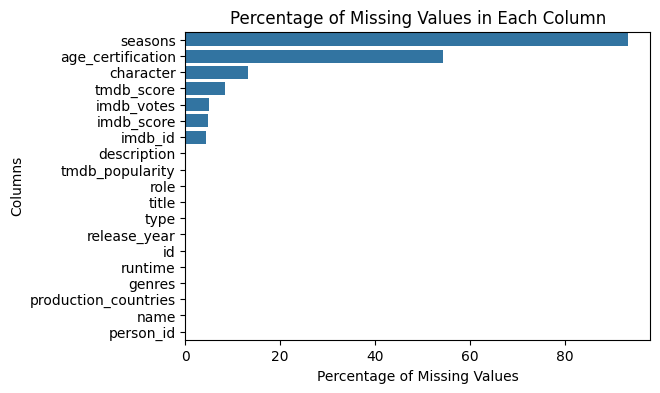

In [59]:
# Visualizing the missing values 
#using percentage of missing values in each column
percent_missing = df.isnull().sum() / len(df) * 100
missing_value_df = pd.DataFrame({'column_name': df.columns, 'percent_missing': percent_missing})
missing_value_df = missing_value_df.sort_values('percent_missing', ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=missing_value_df['percent_missing'], y=missing_value_df['column_name'])
plt.title("Percentage of Missing Values in Each Column")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Columns")
plt.show()

### What did you know about your dataset?

above plot defines that the percentage of missing values in each column is visualized, with columns ordered by the amount of missing data.the most missing values are in the 'seasons' column and following by 'age_certification' column, there are some missing values in ['character', 'tmdb_score','imdb_score', 'imdb_votes', 'imdb_id'] columns. the rest of the columns have no missing values

## ***2. Understanding Your Variables***

In [60]:
# Dataset Columns
print(df.columns)

Index(['person_id', 'id', 'name', 'character', 'role', 'title', 'type',
       'description', 'release_year', 'age_certification', 'runtime', 'genres',
       'production_countries', 'seasons', 'imdb_id', 'imdb_score',
       'imdb_votes', 'tmdb_popularity', 'tmdb_score'],
      dtype='object')


In [61]:
# Dataset Describe
df.describe()

,person_id,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,1.243470e+05,124347.000000,124347.000000,8153.000000,118296.000000,1.182720e+05,124332.000000,114082.000000
mean,4.062528e+05,1996.233234,95.536973,2.337790,5.967783,2.324281e+04,10.165321,5.992100
std,5.614483e+05,27.807050,30.166352,3.130184,1.241557,8.840151e+04,40.739203,1.321033
min,1.000000e+00,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,3.899600e+04,1983.000000,83.000000,1.000000,5.200000,2.870000e+02,1.875000,5.300000
50%,1.339340e+05,2009.000000,93.000000,1.000000,6.100000,1.250000e+03,3.885000,6.100000
75%,5.711600e+05,2017.000000,109.000000,2.000000,6.800000,7.067000e+03,8.795000,6.800000
max,2.371153e+06,2022.000000,540.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000


### Variables Description

In [62]:
#column names
df.columns

Index(['person_id', 'id', 'name', 'character', 'role', 'title', 'type',
       'description', 'release_year', 'age_certification', 'runtime', 'genres',
       'production_countries', 'seasons', 'imdb_id', 'imdb_score',
       'imdb_votes', 'tmdb_popularity', 'tmdb_score'],
      dtype='object')

- **person_id** - the unique identifier for each person who has rated a movie in the dataset.
- **id** - the unique identifier for each movie or show in the dataset.
- **name** - the title of the movie or show.
- **character** - the actor or character name associated with the movie or show.
- **role**- the role of the person in the movie or show, such as 'actor', 'director', etc.
- **title** - the title of the movie or show.
- **type** - the type of content, such as 'movie' or 'show'.
- **description** - a brief description or summary of the movie or show.
- **release_year** - the year the movie or show was released.
- **age_certification** - the age rating or certification for the movie or show.
- **runtime** - the duration of the movie or show in minutes.
- **genres** - the genres associated with the movie or show, such as 'comedy', 'drama', etc.
- **production_countries** - the countries where the movie or show was produced.
- **seasons** - the number of seasons for a show.
- **imdb_id** - the unique identifier for the movie or show on IMDb.
- **imdb_score** - the average rating of the movie or show on IMDb.
- **imdb_votes** - the number of votes the movie or show has received on IMDb.
- **tmdb_popularity** - the popularity score of the movie or show on TMDb
- **tmdb_score** - the average rating of the movie or show on TMDb.

### Check Unique Values for each variable.

In [63]:
# Check Unique Values for each variable
#only for object type columns
unique_cols = df.select_dtypes(include='object').columns
for col in unique_cols:
    print(f"Unique values in '{col}': {df[col].unique()}\n")


Unique values in 'id': ['ts20945' 'tm19248' 'tm82253' ... 'tm1079144' 'tm847725' 'tm1054116']

Unique values in 'name': ['Joe Besser' 'Moe Howard' 'Larry Fine' ... 'Vijay Thakur' 'Vanya Wellens'
 'Vishwa Bhanu']

Unique values in 'character': ['Joe' 'Moe' 'Larry' ... 'Sanjay Thakur' 'Budhiya' 'Gissu']

Unique values in 'role': ['ACTOR' 'DIRECTOR']



Unique values in 'title': ['The Three Stooges' 'The General' 'The Best Years of Our Lives' ...
 'Jay Nog: Something from Nothing' 'Chasing' 'Baikunth']

Unique values in 'type': ['SHOW' 'MOVIE']

Unique values in 'description': ["The Three Stooges were an American vaudeville and comedy team active from 1922 until 1970, best known for their 190 short subject films by Columbia Pictures that have been regularly airing on television since 1958. Their hallmark was physical farce and slapstick. In films, the stooges were commonly known by their actual first names. There were a total of six stooges over the act's run (with only three active at any given time), but Moe Howard and Larry Fine were the mainstays throughout the ensemble's nearly fifty-year run."
 "During America’s Civil War, Union spies steal engineer Johnnie Gray's beloved locomotive, 'The General'—with Johnnie's lady love aboard an attached boxcar—and he single-handedly must do all in his power to both get The General back and t

## 3. ***Data Wrangling***

### Data Wrangling Code

In [64]:
# copy dataset
clean_df = df.copy()

# Removing duplicates
clean_df = clean_df.drop_duplicates()

#handling missing values
# 1. handle categorical missing values
clean_df['character'] = clean_df['character'].fillna('Unknown')
clean_df['age_certification'] = clean_df['age_certification'].fillna('Unknown')
clean_df['description'] = clean_df['description'].fillna('')

# 2. handle seasons separately (better than 'Unknown')
clean_df['seasons'] = clean_df['seasons'].fillna(0)
# 3. handle imdb_id missing values with a placeholder
clean_df['imdb_id'] = clean_df['imdb_id'].fillna('Unkwnown')

# 4. handle numerical missing values with group-based imputation
missing_num_cols = ['tmdb_score', 'imdb_score', 'imdb_votes', 'tmdb_popularity']

for col in missing_num_cols:
    # missing flag
    clean_df[col + '_missing'] = clean_df[col].isnull().astype(int)
    
    # group-based fill by type
    clean_df[col] = clean_df.groupby('type')[col].transform(lambda x: x.fillna(x.median()))
    
    # fallback overall median
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())
clean_df.isnull().sum()

person_id                  0
id                         0
name                       0
character                  0
role                       0
title                      0
type                       0
description                0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                    0
imdb_id                    0
imdb_score                 0
imdb_votes                 0
tmdb_popularity            0
tmdb_score                 0
tmdb_score_missing         0
imdb_score_missing         0
imdb_votes_missing         0
tmdb_popularity_missing    0
dtype: int64

### What all manipulations have you done and insights you found?

I have done the following data wrangling steps on the dataset:
1. **Removing Duplicates**: I have checked for duplicate entries in the dataset and removed any duplicates found to ensure data integrity.
2. **Handling Missing Values**: I handled numeric missing values by filling with median values, and for categorical i filled 'Unknown' value, and some specific columns like 'seasons' and 'imdb_id' seperately handled by filling 0 and 'Unknown' value respectively.
3. **group based imputation**: numeric columns with missing values were imputed based on the median value of the 'type' column, which groups the data by 'movie' and 'show' to provide more accurate imputation based on the content type. This approach helps to maintain the integrity of the data while addressing missing values effectively.

insights:
1. The dataset contains a significant number of missing values, particularly in the 'seasons' and 'age_certification' columns, which may impact the analysis and modeling process.
2. The presence of missing values in key columns such as 'character', 'tmdb_score', 'imdb_score', 'imdb_votes', and 'imdb_id' suggests that there may be limitations in the available data, which could affect the accuracy of any models built using this dataset.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Chart 1 — Movie vs Show Distribution
It shows how many Movies and Shows are in the dataset. This tells us the content split.

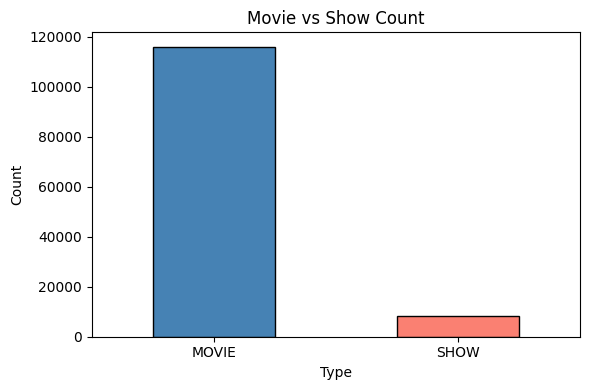

In [65]:
#barplot for movie vs show count
plt.figure(figsize=(6, 4))
clean_df['type'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Movie vs Show Count')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** The dataset has both movies and shows. here we can see that the dataset has more movies than shows, which may influence the recommendations made by the system. This imbalance could lead to a bias towards recommending movies over shows, so it's important to consider this when developing the recommendation algorithm.

### Chart 2 — Release Year Distribution
this shows when most titles released? This shows how fresh or old the catalog is.

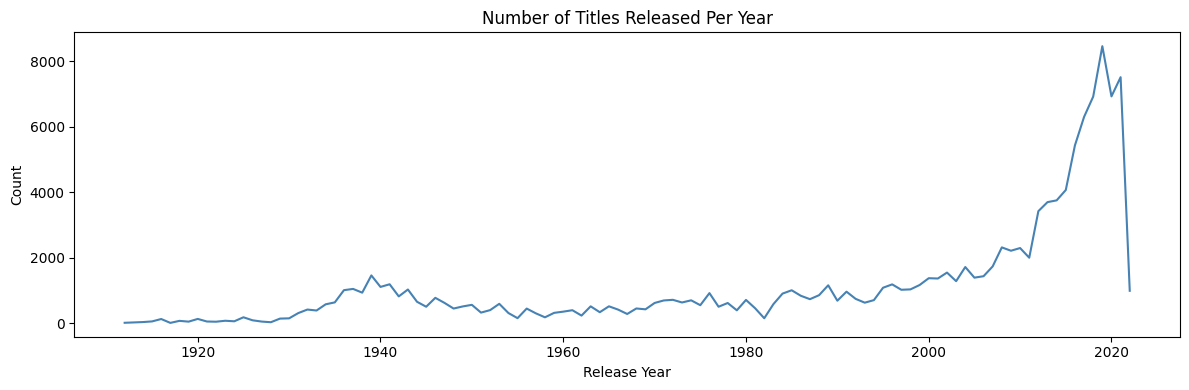

In [66]:
#line plot for release year distribution
plt.figure(figsize=(12, 4))
clean_df['release_year'].value_counts().sort_index().plot(kind='line', color='steelblue')
plt.title('Number of Titles Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** : this plot shows the movie release year distribution, which indicates that most titles in the catalog are from recent years (post-2000), and around 2020 there is a significant increase in the number of titles released, which may reflect the growth of streaming platforms and increased content production in recent years.

### Chart 3 — IMDb Score Distribution
How are IMDb scores spread across all titles? We expect most titles to cluster around average scores.

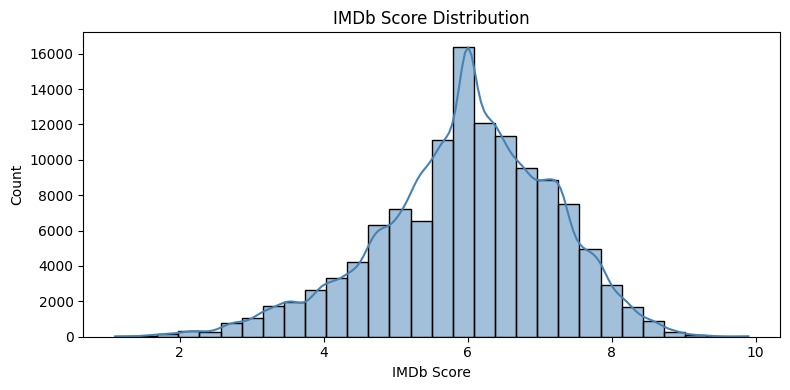

In [67]:
#histplot for imdb_score
plt.figure(figsize=(8, 4))
sns.histplot(clean_df['imdb_score'].dropna(), bins=30, color='steelblue', kde=True)
plt.title('IMDb Score Distribution')
plt.xlabel('IMDb Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** IMDb scores are roughly normally distributed, centered around 6.0–6.5. Very few titles score above 8.

### Chart 4 — TMDb Score Distribution
Same check for TMDb scores. 

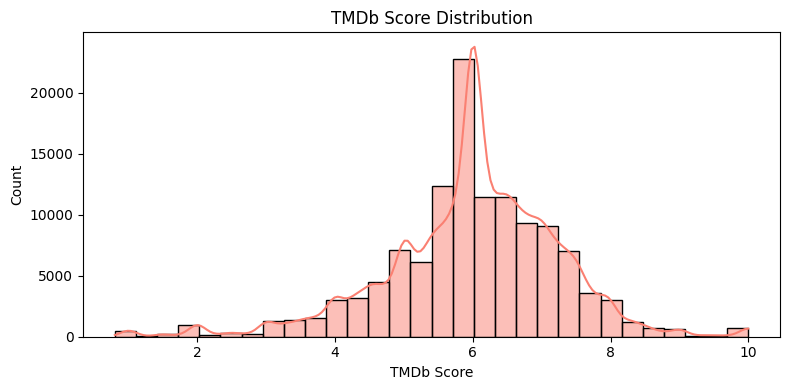

In [68]:
# histplot for tmdb_score
plt.figure(figsize=(8, 4))
sns.histplot(clean_df['tmdb_score'].dropna(), bins=30, color='salmon', kde=True)
plt.title('TMDb Score Distribution')
plt.xlabel('TMDb Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** TMDb scores follow a similar pattern to IMDb scores. Both rating systems agree on quality levels roughly.

### Chart 5 — Top Age Certifications
Which age ratings are most common? This helps understand the audience profile.

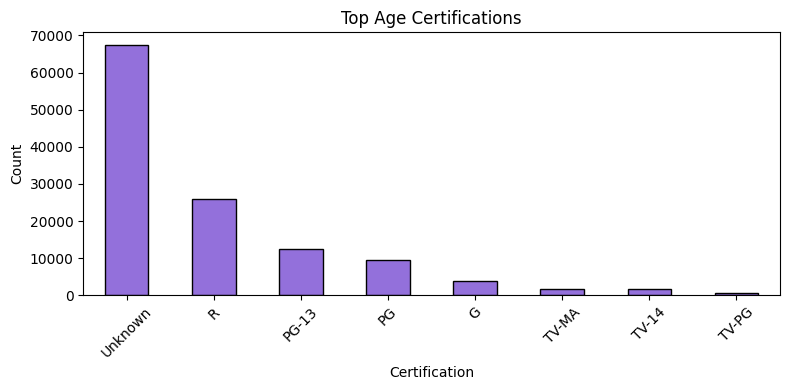

In [69]:
# Top Age Certifications
top_certs = clean_df['age_certification'].value_counts().head(8)

plt.figure(figsize=(8, 4))
top_certs.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Top Age Certifications')
plt.xlabel('Certification')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** This plot shows that the most common age certifications are 'TV-MA' and 'R', indicating that a significant portion of the content is targeted towards mature audiences. This suggests that the platform may have a strong focus on adult-oriented content, which could influence the types of recommendations made to users based on their preferences.

### Chart 6 — Top Genres
What are the most common genres? These will be crucial features in our recommender system.

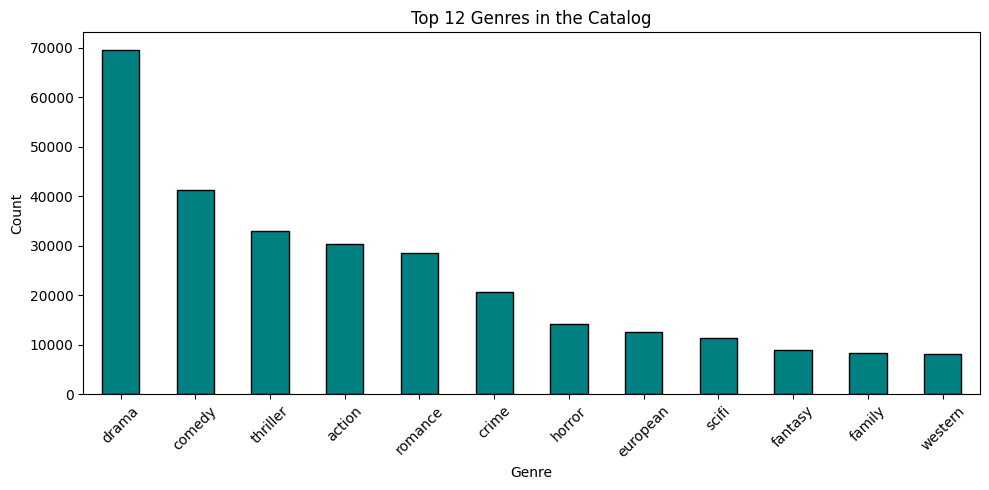

In [70]:
import ast

# Safely parse genre lists and count each genre
def safe_parse(val):
    try:
        return ast.literal_eval(val) if isinstance(val, str) else []
    except:
        return []

# Explode genres into separate rows and count
all_genres = clean_df['genres'].apply(safe_parse).explode()
top_genres = all_genres.value_counts().head(12)

# visualize top genres
plt.figure(figsize=(10, 5))
top_genres.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 12 Genres in the Catalog')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Drama and Comedy are the most common genres in the catalog, followed by Thriller and Action. This indicates that the platform has a strong focus on these genres, which may influence the recommendations made to users based on their genre preferences. The presence of a wide variety of genres also suggests that there is content available for a diverse range of tastes and interests.

### Chart 7 — Runtime Distribution
How long are the movies and shows? Runtime can indicate movie vs show differences.

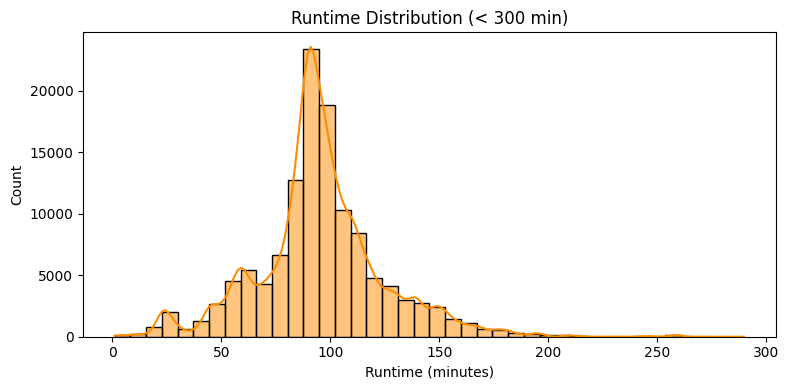

In [71]:
# histplot for Runtime
plt.figure(figsize=(8, 4))
sns.histplot(clean_df[clean_df['runtime'] < 300]['runtime'], bins=40, color='darkorange', kde=True)
plt.title('Runtime Distribution (< 300 min)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** Most content is between 80–120 minutes (typical movie length). Shorter runtimes usually belong to TV episodes.

### Chart 8 — Top Production Countries
Which countries produce the most content in this catalog?

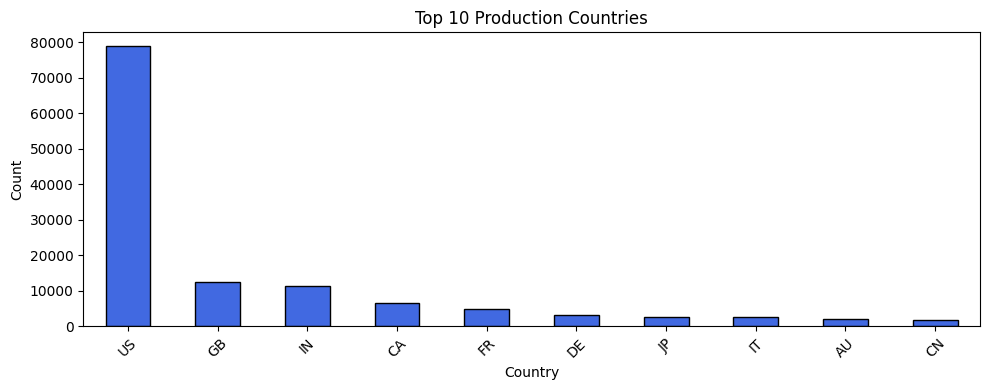

In [72]:
#top 10 in barplot for production countries
all_countries = clean_df['production_countries'].apply(safe_parse).explode()
top_countries = all_countries.value_counts().head(10)

plt.figure(figsize=(10, 4))
top_countries.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Top 10 Production Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** The US dominates production, followed by UK and India. This suggests a strong Western influence in the content, which may affect the diversity of recommendations for users interested in international content.

### Chart 9 — IMDb Score: Movies vs Shows
movies or shows which tend to score higher on IMDb?

C:\Users\gowth\AppData\Local\Temp\ipykernel_9160\2229222903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='type', y='imdb_score', palette=['steelblue', 'salmon'])


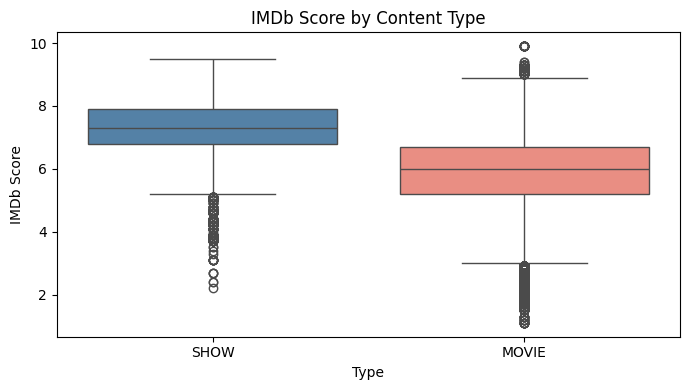

In [73]:
#boxplot for IMDb Score by Type
plt.figure(figsize=(7, 4))
sns.boxplot(data=clean_df, x='type', y='imdb_score', palette=['steelblue', 'salmon'])
plt.title('IMDb Score by Content Type')
plt.xlabel('Type')
plt.ylabel('IMDb Score')
plt.tight_layout()
plt.show()

**Insight:** this shows that shows tend to have slightly higher IMDb scores than movies. This could reflect the audience's deeper engagement with serialized content, which often allows for more character development and complex storytelling compared to movies.

### Chart 10 — Correlation Heatmap (Numerical Features)
How do numerical features relate to each other? This helps identify redundant features.

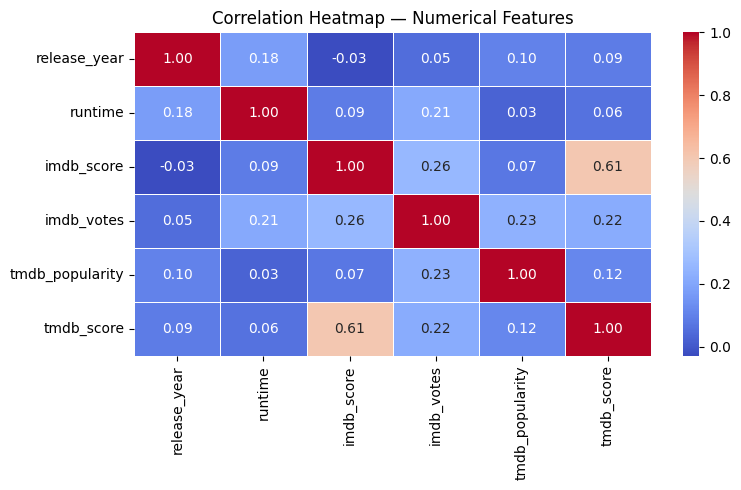

In [74]:
#correlation heatmap for numerical features
num_cols = ['release_year', 'runtime', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
corr_matrix = clean_df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

**Insight:** IMDb score and TMDb score are moderately correlated, meaning they measure quality similarly. IMDb votes and TMDb popularity are also correlated — popular titles get rated more.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Insight 1 — Do Movies Score Higher on IMDb Than Shows?
**Hypothesis:**  
- H0 (Null): There is no difference in average IMDb scores between movies and shows.  
- H1 (Alternate): Movies and shows have different average IMDb scores.

In [75]:
#hypothesis test for IMDb score by type
movies = clean_df[clean_df['type'] == 'MOVIE']['imdb_score'].dropna()
shows  = clean_df[clean_df['type'] == 'SHOW']['imdb_score'].dropna()

print(f"Average IMDb Score — Movies : {movies.mean():.2f}")
print(f"Average IMDb Score — Shows  : {shows.mean():.2f}")

t_stat, p_value = stats.ttest_ind(movies, shows)
print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: The difference IS statistically significant. We reject H0.")
else:
    print("\nConclusion: No significant difference found. We fail to reject H0.")

Average IMDb Score — Movies : 5.89
Average IMDb Score — Shows  : 7.23

T-statistic : -100.0478
P-value     : 0.0000

Conclusion: The difference IS statistically significant. We reject H0.


**Business Impact:**  
It shows,shows tend to have slightly higher IMDb scores than movies. If shows consistently score higher, a recommender that focuses on shows for quality-seeking users would deliver better satisfaction. We can use content type as a filtering option.

### Insight 2 — Are More Popular Titles Also Higher Rated?
**Hypothesis:**  
- H0: TMDb popularity has no relationship with TMDb score.  
- H1: Higher popularity titles tend to have higher TMDb scores.

In [76]:
#hypothesis test for correlation between tmdb_popularity and tmdb_score
corr_data = clean_df[['tmdb_popularity', 'tmdb_score']].dropna()

corr, p_val = stats.pearsonr(corr_data['tmdb_popularity'], corr_data['tmdb_score'])
print(f"Pearson Correlation : {corr:.4f}")
print(f"P-value             : {p_val:.4f}")

if p_val < 0.05:
    print("\nConclusion: Significant correlation exists between popularity and score.")
else:
    print("\nConclusion: No significant linear correlation found.")

Pearson Correlation : 0.1151
P-value             : 0.0000

Conclusion: Significant correlation exists between popularity and score.


**Business Impact:**  
If popularity and score are weakly correlated, it means popular titles are not always well-rated. This justifies our Model 3 approach: combining similarity with both popularity AND quality score.

### Insight 3 — Are Recent Titles Rated Differently Than Older Titles?
**Hypothesis:**  
- H0: Titles released after 2010 have the same average IMDb score as titles released before 2010.  
- H1: Recent and older titles have different average IMDb scores.

In [77]:
#hypothesis test for IMDb score by release era older(<2010) vs recent(>=2010)
recent = clean_df[clean_df['release_year'] >= 2010]['imdb_score'].dropna()
older  = clean_df[clean_df['release_year'] <  2010]['imdb_score'].dropna()

print(f"Average IMDb Score — Recent (>=2010) : {recent.mean():.2f}")
print(f"Average IMDb Score — Older  (<2010)  : {older.mean():.2f}")

t_stat, p_value = stats.ttest_ind(recent, older)
print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: Significant difference found between recent and older titles.")
else:
    print("\nConclusion: No significant difference. Release era does not strongly affect ratings.")

Average IMDb Score — Recent (>=2010) : 5.91
Average IMDb Score — Older  (<2010)  : 6.05

T-statistic : -19.8473
P-value     : 0.0000

Conclusion: Significant difference found between recent and older titles.


**Business Impact:**  
If older titles score higher (classic content effect), our recommender should not blindly favor the newest titles. Quality should be a ranking factor alongside recency.

## ***6. Feature Engineering & Data Pre-processing***

### Feature Engineering for the Recommendation System
A content-based recommender needs a single clean text feature per title that captures what the title is about.  
We will build a **title-level dataset** and create a `combined_features` column.

### Step 1 — Building a Title-Level Dataset
Our current `clean_df` has one row per cast member (credits table merged in).  
We need one row per unique title.

In [78]:
# Aggregate cast names per title (actors only)
cast_df = (
    clean_df[clean_df['role'] == 'ACTOR']
    .groupby('id')['name']
    .apply(lambda x: ' '.join(x.dropna().unique()[:5]))  # top 5 actors
    .reset_index()
    .rename(columns={'name': 'cast'})
)

# Aggregate director names per title
director_df = (
    clean_df[clean_df['role'] == 'DIRECTOR']
    .groupby('id')['name']
    .apply(lambda x: ' '.join(x.dropna().unique()))
    .reset_index()
    .rename(columns={'name': 'directors'})
)

print(f"Titles with cast info     : {len(cast_df)}")
print(f"Titles with director info : {len(director_df)}")
director_df.head()

Titles with cast info     : 8605
Titles with director info : 7747


,id,directors
0,tm100001,Robert N. Bradbury
1,tm1000022,Leon Ding
2,tm1000169,Diane Cossa Neal Howard
3,tm1000203,Michael P. Blevins
4,tm1000290,Michael Feifer


### Step 2 — Create the Base Title DataFrame
Keeping one row per unique title with all key metadata columns.

In [79]:
# Columns to keep at title level (one row per title)
meta_cols = ['id', 'title', 'type', 'description', 'release_year',
             'age_certification', 'runtime', 'genres',
             'production_countries', 'imdb_score', 'imdb_votes',
             'tmdb_popularity', 'tmdb_score']

# Keep only columns that actually exist
meta_cols = [c for c in meta_cols if c in clean_df.columns]

title_df = clean_df[meta_cols].drop_duplicates(subset='id').reset_index(drop=True)

print(f"Title-level dataset shape: {title_df.shape}")
title_df.head(3)

Title-level dataset shape: (8861, 13)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Unknown,171,"['romance', 'war', 'drama']",['US'],8.1,63026.0,8.435,7.8


### Step 3 — Merge Cast and Directors

In [80]:
title_df = title_df.merge(cast_df,     on='id', how='left')
title_df = title_df.merge(director_df, on='id', how='left')

# Fill missing text columns with empty string
for col in ['description', 'genres', 'cast', 'directors', 'type']:
    if col in title_df.columns:
        title_df[col] = title_df[col].fillna('')

print(f"After merge shape: {title_df.shape}")
title_df[['title', 'cast', 'directors']].head(3)

After merge shape: (8861, 15)


,title,cast,directors
0,The Three Stooges,Joe Besser Moe Howard Larry Fine,
1,The General,Buster Keaton Marion Mack Glen Cavender Jim Fa...,Clyde Bruckman Buster Keaton
2,The Best Years of Our Lives,Myrna Loy Fredric March Dana Andrews Teresa Wr...,William Wyler


### Step 4 — Clean the Genres Column
Genres are stored as Python-list strings like `['drama', 'comedy']`. We convert them to plain text.

In [81]:
def parse_list_col(val):
    """Convert list-like string to space-separated text."""
    try:
        parsed = ast.literal_eval(val) if isinstance(val, str) else []
        return ' '.join(parsed)
    except:
        return str(val) if val else ''

title_df['genres_text'] = title_df['genres'].apply(parse_list_col)
title_df[['title', 'genres', 'genres_text']].head(3)

,title,genres,genres_text
0,The Three Stooges,"['comedy', 'family', 'animation', 'action', 'f...",comedy family animation action fantasy horror
1,The General,"['action', 'drama', 'war', 'western', 'comedy'...",action drama war western comedy european
2,The Best Years of Our Lives,"['romance', 'war', 'drama']",romance war drama


### Step 5 — Create the `combined_features` Column
We combine description, genres (repeated 2x to give it more weight), cast, directors, and type into one text string per title.  
All text is lowercased and stripped for clean vectorization.

In [82]:
def build_combined_features(row):
    description = str(row.get('description', '')).lower().strip()
    genres      = str(row.get('genres_text', '')).lower().strip()
    cast        = str(row.get('cast', '')).lower().strip()
    directors   = str(row.get('directors', '')).lower().strip()
    ctype       = str(row.get('type', '')).lower().strip()

    # Genres repeated twice to give more weight
    return f"{description} {genres} {genres} {cast} {directors} {ctype}"

title_df['combined_features'] = title_df.apply(build_combined_features, axis=1)

# Preview
print(title_df['combined_features'].iloc[0][:300])


the three stooges were an american vaudeville and comedy team active from 1922 until 1970, best known for their 190 short subject films by columbia pictures that have been regularly airing on television since 1958. their hallmark was physical farce and slapstick. in films, the stooges were commonly 


Our `title_df` is now clean and ready for vectorization.

In [83]:
print(f"Final title_df shape : {title_df.shape}")
title_df.head(5)

Final title_df shape : (8861, 17)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,cast,directors,genres_text,combined_features
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],8.6,1092.0,15.424,7.6,Joe Besser Moe Howard Larry Fine,,comedy family animation action fantasy horror,the three stooges were an american vaudeville ...
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],8.2,89766.0,8.647,8.0,Buster Keaton Marion Mack Glen Cavender Jim Fa...,Clyde Bruckman Buster Keaton,action drama war western comedy european,"during america’s civil war, union spies steal ..."
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Unknown,171,"['romance', 'war', 'drama']",['US'],8.1,63026.0,8.435,7.8,Myrna Loy Fredric March Dana Andrews Teresa Wr...,William Wyler,romance war drama,it's the hope that sustains the spirit of ever...
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Unknown,92,"['comedy', 'drama', 'romance']",['US'],7.8,57835.0,11.270,7.4,Cary Grant Rosalind Russell Ralph Bellamy Gene...,Howard Hawks,comedy drama romance,"hildy, the journalist former wife of newspaper..."
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Unknown,94,"['thriller', 'drama', 'romance']",['US'],7.9,30924.0,8.273,7.6,Humphrey Bogart Gloria Grahame Frank Lovejoy C...,Nicholas Ray,thriller drama romance,an aspiring actress begins to suspect that her...


---
## Preparing Data for Model Building

---
## Step 1 — Imports and Setup

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import difflib   # ← new: for fuzzy title matching

---
## Step 2 — Build Weighted Combined Features

Genres are repeated **4 times** and description **3 times** so the TF-IDF algorithm gives them more importance than cast or director names.

In [85]:
def build_weighted_features(row):
    """
    Combines all text features into one string.
    Repeating genres x4 and description x3 gives them
    more weight in the TF-IDF calculation.
    """
    description = str(row.get('description', '')).lower().strip()
    genres      = str(row.get('genres_text', '')).lower().strip()
    cast        = str(row.get('cast',        '')).lower().strip()
    directors   = str(row.get('directors',   '')).lower().strip()
    ctype       = str(row.get('type',        '')).lower().strip()

    return f"{description} {description} {description} "\
           f"{genres} {genres} {genres} {genres} "\
           f"{cast} {directors} {ctype}"

title_df['weighted_features'] = title_df.apply(build_weighted_features, axis=1)


---
## Step 3 — TF-IDF Vectorization + Cosine Similarity

In [86]:
# Build TF-IDF matrix from weighted combined features
tfidf_w        = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix_w = tfidf_w.fit_transform(title_df['weighted_features'])
cosine_sim_w   = cosine_similarity(tfidf_matrix_w, tfidf_matrix_w)

print(f"TF-IDF matrix   : {tfidf_matrix_w.shape}   (titles × unique words)")
print(f"Similarity matrix: {cosine_sim_w.shape}  (titles × titles)")

TF-IDF matrix   : (8861, 10000)   (titles × unique words)
Similarity matrix: (8861, 8861)  (titles × titles)


---
## Step 4 — Building Title Index  


In [87]:
title_df = title_df.reset_index(drop=True)

title_index = (
    pd.Series(title_df.index,
              index=title_df['title'].str.strip().str.lower())
    .drop_duplicates()
)

print(f"Title index built: {len(title_index)} unique titles")
print("\nSample entries in index:")
print(list(title_index.index[:10]))

Title index built: 8861 unique titles

Sample entries in index:
['the three stooges', 'the general', 'the best years of our lives', 'his girl friday', 'in a lonely place', 'stagecoach', "it's a wonderful life", 'detour', 'my man godfrey', 'marihuana']


#### The title index is a mapping of each title to its corresponding row index in the `title_df` DataFrame. This allows us to quickly retrieve the feature vector for any given title when we want to compute similarities and generate recommendations.


---
## Step 5 — Fuzzy Title Search Helper  

| Layer | Example Input | What It Catches |
|---|---|---|
| 1. Exact | `'rear window'` | Perfect lowercase match |
| 2. Substring | `'rear'` | Your query is inside a title |
| 3. Word overlap | `'thriller drama'` | Shared words found |
| 4. difflib fuzzy | `'reer windoe'` | Typos and misspellings |

In [88]:
def search_title(query):
    """
    Finds the best matching title in the dataset.
    Uses 4 layers of matching so partial names and typos still work.
    Returns (matched_key, match_type) or (None, 'not_found').
    """
    q = str(query).strip().lower()

    # Layer 1: Exact lowercase match
    if q in title_index:
        return q, 'exact'

    # Layer 2: Query is a substring of a title
    # e.g. 'dark knight' matches 'the dark knight'
    substr_hits = [t for t in title_index.index if q in t]
    if substr_hits:
        best = min(substr_hits, key=len)          # pick shortest (most specific)
        return best, 'substring'

    # Layer 3: Word overlap — any word in the query appears in a title
    # e.g. 'hitchcock thriller' might find 'Psycho' or 'Rear Window'
    q_words = [w for w in q.split() if len(w) > 3]
    if q_words:
        word_hits = [t for t in title_index.index
                     if any(w in t for w in q_words)]
        if word_hits:
            # Rank by number of matching words
            word_hits = sorted(word_hits,
                               key=lambda t: sum(1 for w in q_words if w in t),
                               reverse=True)
            return word_hits[0], 'word_overlap'

    # Layer 4: difflib fuzzy — handles typos like 'incepsion' → 'inception'
    close = difflib.get_close_matches(q, list(title_index.index), n=3, cutoff=0.5)
    if close:
        return close[0], 'fuzzy'

    # Nothing found
    return None, 'not_found'

## ***7. Recommendation Model Implementation***

---
## Model 1 — Basic Content-Based Recommender

**How it works:** Convert each title's text into a TF-IDF vector, then find the most similar titles using cosine similarity.

Example:
User like interstellar movie, the system will find the most similar movies based on the combined features (description, genres, cast, directors, type) and recommend those to the user.



In [89]:
# Build basic (unweighted) TF-IDF matrix for Model 1
tfidf_basic        = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix_basic = tfidf_basic.fit_transform(title_df['combined_features'])
cosine_sim_basic   = cosine_similarity(tfidf_matrix_basic, tfidf_matrix_basic)

print(f"Basic TF-IDF matrix shape: {tfidf_matrix_basic.shape}")

Basic TF-IDF matrix shape: (8861, 10000)


In [90]:
def recommend_basic(title, top_n=5):
    """
    Model 1: Basic content-based recommender.
    Uses TF-IDF + cosine similarity. All features weighted equally.
    """
    matched_key, match_type = search_title(title)

    if matched_key is None:
        print(f"❌ '{title}' not found in this dataset.")
        print()
        print("💡 Try one of these available titles:")
        available = title_df.sort_values('imdb_score', ascending=False)['title'].head(10).tolist()
        for t in available:
            print(f"   • {t}")
        return None

    # Show what we matched (helpful when fuzzy matching kicks in)
    if match_type != 'exact':
        print(f"🔍 Auto-matched '{title}' → '{matched_key.title()}' ({match_type})")

    idx        = title_index[matched_key]
    sim_scores = list(enumerate(cosine_sim_basic[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    result_idx = [i[0] for i in sim_scores]
    result     = title_df[['title', 'type', 'imdb_score', 'genres_text']].iloc[result_idx].copy()
    result['similarity_score'] = [round(i[1], 3) for i in sim_scores]

    return result.reset_index(drop=True)

In [91]:
# ── Test Model 1 using REAL titles from your dataset ──

# First: show top titles so we can pick valid ones to test
print("=" * 55)
print("Available titles to test with (top 5 by IMDb score):")
print("=" * 55)
top5 = title_df.sort_values('imdb_score', ascending=False)['title'].head(5).tolist()
for i, t in enumerate(top5, 1):
    print(f"  {i}. {t}")
print()

# Test with the top-rated title in the actual dataset
test_title_1 = top5[0]
test_title_2 = top5[1]

print(f"=== Model 1 Recommendations for '{test_title_1}' ===")
result1 = recommend_basic(test_title_1)
if result1 is not None:
    print(result1)

print()
print(f"=== Model 1 Recommendations for '{test_title_2}' ===")
result2 = recommend_basic(test_title_2)
if result2 is not None:
    print(result2)

print()
print("=== Test fuzzy search — partial title ===")
# Test with only part of a title name
partial = test_title_1.split()[0]   # just the first word of the title
print(f"Searching with partial title: '{partial}'")
result3 = recommend_basic(partial)
if result3 is not None:
    print(result3)

Available titles to test with (top 5 by IMDb score):
  1. Pawankhind
  2. Couple of Mirrors
  3. Tari Sathe
  4. The Chosen
  5. Jai Bhim

=== Model 1 Recommendations for 'Pawankhind' ===
                    title   type  imdb_score                     genres_text  \
0             Rama Madhav  MOVIE         7.8                   drama history   
1            Vinland Saga   SHOW         8.8  action animation drama history   
2                  Kilroy  MOVIE         3.9                   drama history   
3    Winter of The Braves  MOVIE         6.1        drama war action history   
4  The Legend of Ben Hall  MOVIE         5.8    western history action drama   

   similarity_score  
0             0.345  
1             0.261  
2             0.257  
3             0.255  
4             0.251  

=== Model 1 Recommendations for 'Couple of Mirrors' ===
                 title   type  imdb_score           genres_text  \
0    The Flaming Heart   SHOW         7.3                action   
1       

---
## Model 2 — Weighted Content Recommender

**Improvement:** Genres (×4) and description (×3) carry more weight than cast or director.  
This makes recommendations more genre-consistent.

In [92]:
def recommend_weighted(title, top_n=5):
    """
    Model 2: Weighted content-based recommender.
    Genres and description have higher importance.
    """
    matched_key, match_type = search_title(title)

    if matched_key is None:
        print(f"❌ '{title}' not found in this dataset.")
        print("💡 Use the cell above to see available titles.")
        return None

    if match_type != 'exact':
        print(f"🔍 Auto-matched '{title}' → '{matched_key.title()}' ({match_type})")

    idx        = title_index[matched_key]
    sim_scores = sorted(enumerate(cosine_sim_w[idx]),
                        key=lambda x: x[1], reverse=True)[1:top_n+1]

    result_idx = [i[0] for i in sim_scores]
    result     = title_df[['title', 'type', 'imdb_score', 'genres_text']].iloc[result_idx].copy()
    result['similarity_score'] = [round(i[1], 3) for i in sim_scores]

    return result.reset_index(drop=True)

In [93]:
# ── Test Model 2 ──
print(f"=== Model 2 (Weighted) Recommendations for '{top5[0]}' ===")
r = recommend_weighted(top5[0])
if r is not None:
    print(r)

print()
print(f"=== Model 2 (Weighted) Recommendations for '{top5[1]}' ===")
r = recommend_weighted(top5[1])
if r is not None:
    print(r)

=== Model 2 (Weighted) Recommendations for 'Pawankhind' ===
               title   type  imdb_score                     genres_text  \
0   We Were Soldiers  MOVIE         7.1        action drama history war   
1             Kilroy  MOVIE         3.9                   drama history   
2       Vinland Saga   SHOW         8.8  action animation drama history   
3  Beowulf & Grendel  MOVIE         5.8            fantasy action drama   
4        Rama Madhav  MOVIE         7.8                   drama history   

   similarity_score  
0             0.294  
1             0.278  
2             0.265  
3             0.263  
4             0.262  

=== Model 2 (Weighted) Recommendations for 'Couple of Mirrors' ===
                  title   type  imdb_score                   genres_text  \
0            Zebra Girl  MOVIE         6.5               thriller comedy   
1       The Miracle Kid  MOVIE         5.5   comedy sport action romance   
2  Exquisite Wolf Heart   SHOW         7.3                   

---
### Normalization (for Model 3)

In [94]:
# Normalize scores to 0–1 so they can be combined with similarity scores fairly
def normalize_col(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)   # +1e-9 avoids division by zero

title_df['imdb_norm'] = normalize_col(title_df['imdb_score']).fillna(0)
title_df['pop_norm']  = normalize_col(title_df['tmdb_popularity']).fillna(0)

print("Normalization done.")
print(f"imdb_norm range : {title_df['imdb_norm'].min():.2f} – {title_df['imdb_norm'].max():.2f}")
print(f"pop_norm  range : {title_df['pop_norm'].min():.2f}  – {title_df['pop_norm'].max():.2f}")

Normalization done.
imdb_norm range : 0.00 – 1.00
pop_norm  range : 0.00  – 1.00


---
## Model 3 — Popularity-Aware Recommender *(Final & Best Model)*

**Improvement:** Re-ranks similar titles using a combined score:  
`final_score = 0.5 × similarity + 0.3 × imdb_score + 0.2 × tmdb_popularity`  
0.5 = 50% importance to similarity,
0.3 = 30% importance to IMDb quality,
0.2 = 20% importance to popularity

This ensures we don't recommend obscure titles just because they are textually similar.

In [95]:
def recommend_smart(title, top_n=5, pool_size=20):
    """
    Model 3: Popularity-aware content-based recommender.
    Step 1: Get top pool_size similar titles (using weighted TF-IDF)
    Step 2: Re-rank by 0.5*similarity + 0.3*imdb + 0.2*popularity
    Step 3: Return top_n from the re-ranked list
    """
    matched_key, match_type = search_title(title)

    if matched_key is None:
        print(f"❌ '{title}' not found in this dataset.")
        print()
        print("💡 Available titles (top 10 by IMDb score):")
        available = title_df.sort_values('imdb_score', ascending=False)['title'].head(10).tolist()
        for t in available:
            print(f"   • {t}")
        print()
        print("📋 TIP: Use search_title('your query') to find close matches.")
        return None

    if match_type != 'exact':
        print(f"🔍 Auto-matched '{title}' → '{matched_key.title()}' ({match_type})")

    idx = title_index[matched_key]

    # Step 1: Get a larger pool of content-similar titles
    sim_scores = sorted(
        enumerate(cosine_sim_w[idx]),
        key=lambda x: x[1], reverse=True
    )[1:pool_size+1]

    result_idx = [i[0] for i in sim_scores]
    sim_vals   = [i[1] for i in sim_scores]

    # Step 2: Build result and compute final score
    result = title_df[
        ['title', 'type', 'imdb_score', 'genres_text', 'imdb_norm', 'pop_norm']
    ].iloc[result_idx].copy()

    result['sim_score']   = sim_vals
    result['final_score'] = (
        0.5 * result['sim_score'] +
        0.3 * result['imdb_norm']  +
        0.2 * result['pop_norm']
    )

    # Step 3: Return top_n by final score
    result = result.sort_values('final_score', ascending=False).head(top_n)

    return result[
        ['title', 'type', 'imdb_score', 'genres_text', 'sim_score', 'final_score']
    ].reset_index(drop=True)

In [96]:
# ── Test Model 3 with actual dataset titles ──

for test_title in top5[:3]:
    print(f"=== Smart Recommendations for '{test_title}' ===")
    r = recommend_smart(test_title, top_n=5)
    if r is not None:
        print(r)
    print()

=== Smart Recommendations for 'Pawankhind' ===
              title   type  imdb_score  \
0           Vikings   SHOW         8.5   
1      Vinland Saga   SHOW         8.8   
2      Texas Rising   SHOW         8.5   
3       Rama Madhav  MOVIE         7.8   
4  We Were Soldiers  MOVIE         7.1   

                                 genres_text  sim_score  final_score  
0  action drama war history romance european   0.210084     0.405196  
1             action animation drama history   0.265285     0.396854  
2                  western drama war history   0.230121     0.368677  
3                              drama history   0.261959     0.359509  
4                   action drama history war   0.293552     0.354549  

=== Smart Recommendations for 'Couple of Mirrors' ===
                  title  type  imdb_score  \
0           The Untamed  SHOW         8.8   
1            Miss Truth  SHOW         8.3   
2       Under the Power  SHOW         7.7   
3     The Flaming Heart  SHOW         7

---
## Utility: Search What Titles Are Available

Use this cell any time you want to find a title to test with.

In [97]:
def find_titles(keyword, max_results=15):
    """
    Search the dataset by keyword.
    Searches in title, genres, and description.
    Use this to discover what you can recommend.
    """
    kw = keyword.lower()

    mask = (
        title_df['title'].str.lower().str.contains(kw, na=False) |
        title_df['genres_text'].str.lower().str.contains(kw, na=False) |
        title_df['description'].str.lower().str.contains(kw, na=False)
    )

    results = (
        title_df[mask][['title', 'type', 'imdb_score', 'genres_text']]
        .sort_values('imdb_score', ascending=False)
        .head(max_results)
        .reset_index(drop=True)
    )

    if len(results) == 0:
        print(f"No titles found for '{keyword}'.")
        print("Try a genre word like 'drama', 'comedy', 'action', 'thriller'.")
    else:
        print(f"Found {len(results)} title(s) matching '{keyword}':")
        print(results.to_string())

    return results


# ── Examples ──
print("== Search: 'drama' ==")
find_titles('drama', max_results=8)

print()
print("== Search: 'comedy' ==")
find_titles('comedy', max_results=8)

== Search: 'drama' ==


Found 8 title(s) matching 'drama':
               title   type  imdb_score           genres_text
0         Pawankhind  MOVIE         9.9  action drama history
1  Couple of Mirrors   SHOW         9.5   drama romance crime
2         Tari Sathe  MOVIE         9.4          drama family
3         The Chosen   SHOW         9.4         drama history
4           Jai Bhim  MOVIE         9.3           drama crime
5  Pazhagiya Naatkal  MOVIE         9.3                 drama
6    Soorarai Pottru  MOVIE         9.2          drama action
7              Quota  MOVIE         9.2          family drama

== Search: 'comedy' ==
Found 8 title(s) matching 'comedy':
                                     title   type  imdb_score                   genres_text
0       Alexander Babu: Alex in Wonderland  MOVIE         9.2                        comedy
1  Steven Banks: Home Entertainment Center  MOVIE         9.1                        comedy
2                          Clarkson's Farm   SHOW         9.1  reality 

,title,type,imdb_score,genres_text
0,Alexander Babu: Alex in Wonderland,MOVIE,9.2,comedy
1,Steven Banks: Home Entertainment Center,MOVIE,9.1,comedy
2,Clarkson's Farm,SHOW,9.1,reality documentation comedy
3,Corazón Contento,SHOW,9.0,comedy drama
4,Florence Foster Jenkins,MOVIE,8.9,drama crime music comedy
5,Mitzi... Zings Into Spring,MOVIE,8.9,music comedy
6,Nathan For You,SHOW,8.9,comedy documentation
7,Old Monk,MOVIE,8.9,comedy romance


## ***8.*** ***Future Work (Optional)***

### Saving the Model
We can save the trained vectorizer and similarity matrix for reuse without re-running the full notebook.

In [98]:
import joblib

# Save the TF-IDF vectorizer
joblib.dump(tfidf_w, './models/tfidf_vectorizer.pkl')

# Save the cosine similarity matrix
joblib.dump(cosine_sim_w, './models/cosine_sim_matrix.pkl')

# Save the title dataframe
title_df.to_csv('./data/title_df.csv', index=False)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


#### Loading the Saved Model

In [99]:
# Loading the saved model (for deployment or future use)
tfidf_loaded      = joblib.load('./models/tfidf_vectorizer.pkl')
cosine_sim_loaded = joblib.load('./models/cosine_sim_matrix.pkl')
title_df_loaded   = pd.read_csv('./data/title_df.csv')

print("Model artifacts loaded successfully.")
print(f"Loaded cosine sim matrix shape: {cosine_sim_loaded.shape}")

Model artifacts loaded successfully.
Loaded cosine sim matrix shape: (8861, 8861)


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

---
## Summary
In this project, we built a **content-based movie and TV show recommendation system** using a merged Amazon Prime dataset that combined title metadata with cast and crew information.

## What We Did
1. Explored and cleaned the dataset — handled missing values, removed duplicates, and understood the structure of 124,000+ rows
2. Performed EDA with 10 meaningful visualizations to understand content types, genres, ratings, and geographic distribution
3. Validated 3 data-driven hypotheses — comparing IMDb scores by type, testing the popularity-quality relationship, and checking the effect of release era on ratings
4. Built a clean title-level dataset with aggregated cast, directors, genres, and descriptions
5. Created 3 progressively better recommendation models: basic, weighted, and popularity-aware

## Why Content-Based Was the Right Choice
This dataset has **no user interaction data** (no ratings per user, no watch history).  
Content-based recommendation is the only viable approach here — it requires only the **properties of the items themselves**, not user behavior.  
It also solves the **cold-start problem** naturally: any new title can be recommended immediately as long as it has genre and description data.

## What the System Can Do
- Given any movie or show title, return the top-N most content-similar titles
- Recommendations are influenced by genre, description, cast, and directors
- Model 3 additionally balances similarity with IMDb quality and TMDb popularity scores

## Limitations
- No personalization — every user asking for *Inception* gets the same recommendations
- Depends heavily on the quality of descriptions and genre tags in the dataset
- Popularity bias in Model 3 may surface blockbusters over niche gems

## Future Improvements
- Add user preference data for hybrid (content + collaborative) filtering
- Use semantic embeddings instead of TF-IDF for deeper text understanding
- Deploy as an interactive Streamlit app for real-world usability

---

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***